Uploading the file

In [1]:
from google.colab import files

uploaded = files.upload()

Saving Presentation-TASK.xlsx to Presentation-TASK.xlsx


In [3]:
import pandas as pd
df = pd.read_excel("Presentation-TASK.xlsx")
df.head(50)

,UID,Participant Name,Unnamed: 2,Project Name,Technical knowledge,Communication,Attrire,Marks
0,NaN,NaN,Group No,NaN,10,10.0,5.0,NaN
1,T160600201,Gayathri Munasu,3,"types of Data visuals,application",6,6.0,3.0,NaN
2,T160600202,Namratha Bajjuri,4,Comparision of t-SNE,6,6.0,4.0,NaN
3,T160600203,Nikitha Sambangi,NaN,NaN,NaN,NaN,NaN,NaN
4,T160600204,Akhil Reddy Komireddy,3,KNN,6,7.0,3.0,NaN
5,T160600205,CHARAN KONDA,3,"Applications of SVM ,",6,7.0,3.0,NaN
6,T160600206,Md Faisal,4,Functions,6,6.0,4.0,NaN
7,T160600207,BOPPANI BHARGAVI,2,Feature Engineering (numeric),8,7.0,4.0,NaN
8,T160600208,AjithReddy Anumandla,6,NaN,7,6.0,3.0,NaN
9,T160600209,Divyasri Maradana,6,NaN,NaN,NaN,NaN,NaN


In [4]:
#Check column names
df.columns

Index(['UID', 'Participant Name', 'Unnamed: 2', 'Project Name',
       'Technical knowledge', 'Communication', 'Attrire', 'Marks'],
      dtype='object')

In [5]:
#Check Missing Values
df.isnull().sum()


,0
UID,14
Participant Name,8
Unnamed: 2,23
Project Name,49
Technical knowledge,24
Communication,28
Attrire,30
Marks,85


In [6]:
#Remove Missing Values

df = df.dropna()


In [7]:
#Check again
df.isnull().sum()

,0
UID,0
Participant Name,0
Unnamed: 2,0
Project Name,0
Technical knowledge,0
Communication,0
Attrire,0
Marks,0


Create Total Marks

In [8]:
#Assuming the columns are named

# Technical
# Communication
# Attire
# Rename 'Marks' column to 'Total Marks'
df.rename(columns={"Marks": "Total Marks"}, inplace=True)
df.head()

,UID,Participant Name,Unnamed: 2,Project Name,Technical knowledge,Communication,Attrire,Total Marks


In [9]:

import pandas as pd

# Read Excel using the first row as header
df = pd.read_excel("Presentation-TASK.xlsx")

# Remove the second row (maximum marks row)
df = df.iloc[1:].reset_index(drop=True)

# Remove rows where participant name is missing
df = df.dropna(subset=["Participant Name"])

# Convert marks columns to numeric
df["Technical knowledge"] = pd.to_numeric(df["Technical knowledge"], errors="coerce")
df["Communication"] = pd.to_numeric(df["Communication"], errors="coerce")
df["Attrire"] = pd.to_numeric(df["Attrire"], errors="coerce")

# Calculate Total Marks
df["Total Marks"] = (
    df["Technical knowledge"] +
    df["Communication"] +
    df["Attrire"]
)

# Display total marks of every participant
df[["Participant Name", "Technical knowledge", "Communication", "Attrire", "Total Marks"]]


,Participant Name,Technical knowledge,Communication,Attrire,Total Marks
0,Gayathri Munasu,6.0,6.0,3.0,15.0
1,Namratha Bajjuri,6.0,6.0,4.0,16.0
2,Nikitha Sambangi,NaN,NaN,NaN,NaN
3,Akhil Reddy Komireddy,6.0,7.0,3.0,16.0
4,CHARAN KONDA,6.0,7.0,3.0,16.0
...,...,...,...,...,...
77,Created seperate colabs for each topic,NaN,NaN,NaN,NaN
79,Hand gestures,NaN,NaN,NaN,NaN
80,distractions,NaN,NaN,NaN,NaN
82,need to distribute the concepts equally,NaN,NaN,NaN,NaN


Top 5 Students Based on Total Marks

In [10]:
top5_total = df.sort_values(by="Total Marks", ascending=False).head(5)

top5_total[["Participant Name", "Total Marks"]]

,Participant Name,Total Marks
6,BOPPANI BHARGAVI,19.0
64,Gajula Sathvika,19.0
22,Kanigiri Devika,18.0
44,SRI SAI MADHURVIND MUDUTHANAPELLY,18.0
28,Mohammed Masoom Baba,18.0


In [11]:
#Visualization
import plotly.express as px
fig = px.bar(
    top5_total,
    x="Participant Name",
    y="Total Marks",
    color="Total Marks",
    text="Total Marks",
    title="Top 5 Students Based on Total Marks"
)

fig.update_traces(textposition="outside")
fig.show()

Top 5 Students in Technical

In [12]:

top_technical = df.sort_values(by="Technical knowledge", ascending=False).head(5)

print("Top 5 Students in Technical")
print(top_technical[["Participant Name", "Technical knowledge"]])

Top 5 Students in Technical
                     Participant Name  Technical knowledge
6                    BOPPANI BHARGAVI                  8.0
44  SRI SAI MADHURVIND MUDUTHANAPELLY                  8.0
64                    Gajula Sathvika                  8.0
7                AjithReddy Anumandla                  7.0
21                Madipadiga Kousheel                  7.0


In [13]:
#visualization
fig = px.bar(
    top_technical,
    x="Participant Name",
    y="Technical knowledge",
    color="Technical knowledge",
    text="Technical knowledge",
    title="Top 5 Students in Technical"
)

fig.update_traces(textposition="outside")
fig.show()


Top 5 Students in Communication

In [14]:
top_communication = df.sort_values(by="Communication", ascending=False).head(5)

print("Top 5 Students in Communication")
print(top_communication[["Participant Name", "Communication"]])

Top 5 Students in Communication
                Participant Name  Communication
4                   CHARAN KONDA            7.0
3          Akhil Reddy Komireddy            7.0
6               BOPPANI BHARGAVI            7.0
17  PEETHALA JYOTHI SWAROOP BABU            7.0
22               Kanigiri Devika            7.0


In [15]:
#visualiztion
fig = px.bar(
    top_communication,
    x="Participant Name",
    y="Communication",
    color="Communication",
    text="Communication",
    title="Top 5 Students in Communication"
)

fig.update_traces(textposition="outside")
fig.show()

Top 5 Students in Attire

In [16]:
top_attire = df.sort_values(by="Attrire", ascending=False).head(5)

print("Top 5 Students in Attire")
print(top_attire[["Participant Name", "Attrire"]])

Top 5 Students in Attire
        Participant Name  Attrire
35        Vaishnavi Erla      5.0
28  Mohammed Masoom Baba      5.0
5              Md Faisal      4.0
12    Akshitha Samudrala      4.0
1       Namratha Bajjuri      4.0


In [17]:
#visualization
fig = px.bar(
    top_attire,
    x="Participant Name",
    y="Attrire",
    color="Attrire",
    text="Attrire",
    title="Top 5 Students in Attire"
)

fig.update_traces(textposition="outside")
fig.show()


In [18]:
#Display All Rankings Nicely
print("\n===== Top 5 Students Based on Total Marks =====")
print(top5_total[["Participant Name", "Total Marks"]])

print("\n===== Top 5 Students in Technical =====")
print(top_technical[["Participant Name", "Technical knowledge"]])

print("\n===== Top 5 Students in Communication =====")
print(top_communication[["Participant Name", "Communication"]])

print("\n===== Top 5 Students in Attire =====")
print(top_attire[["Participant Name", "Attrire"]])


===== Top 5 Students Based on Total Marks =====
                     Participant Name  Total Marks
6                    BOPPANI BHARGAVI         19.0
64                    Gajula Sathvika         19.0
22                    Kanigiri Devika         18.0
44  SRI SAI MADHURVIND MUDUTHANAPELLY         18.0
28               Mohammed Masoom Baba         18.0

===== Top 5 Students in Technical =====
                     Participant Name  Technical knowledge
6                    BOPPANI BHARGAVI                  8.0
44  SRI SAI MADHURVIND MUDUTHANAPELLY                  8.0
64                    Gajula Sathvika                  8.0
7                AjithReddy Anumandla                  7.0
21                Madipadiga Kousheel                  7.0

===== Top 5 Students in Communication =====
                Participant Name  Communication
4                   CHARAN KONDA            7.0
3          Akhil Reddy Komireddy            7.0
6               BOPPANI BHARGAVI            7.0
17  PEETHALA 

In [19]:
# Distribution of Total Marks (Histogram)
fig = px.histogram(
    df,
    x="Total Marks",
    nbins=10,
    title="Distribution of Total Marks"
)

fig.show()

Creating Dashboard

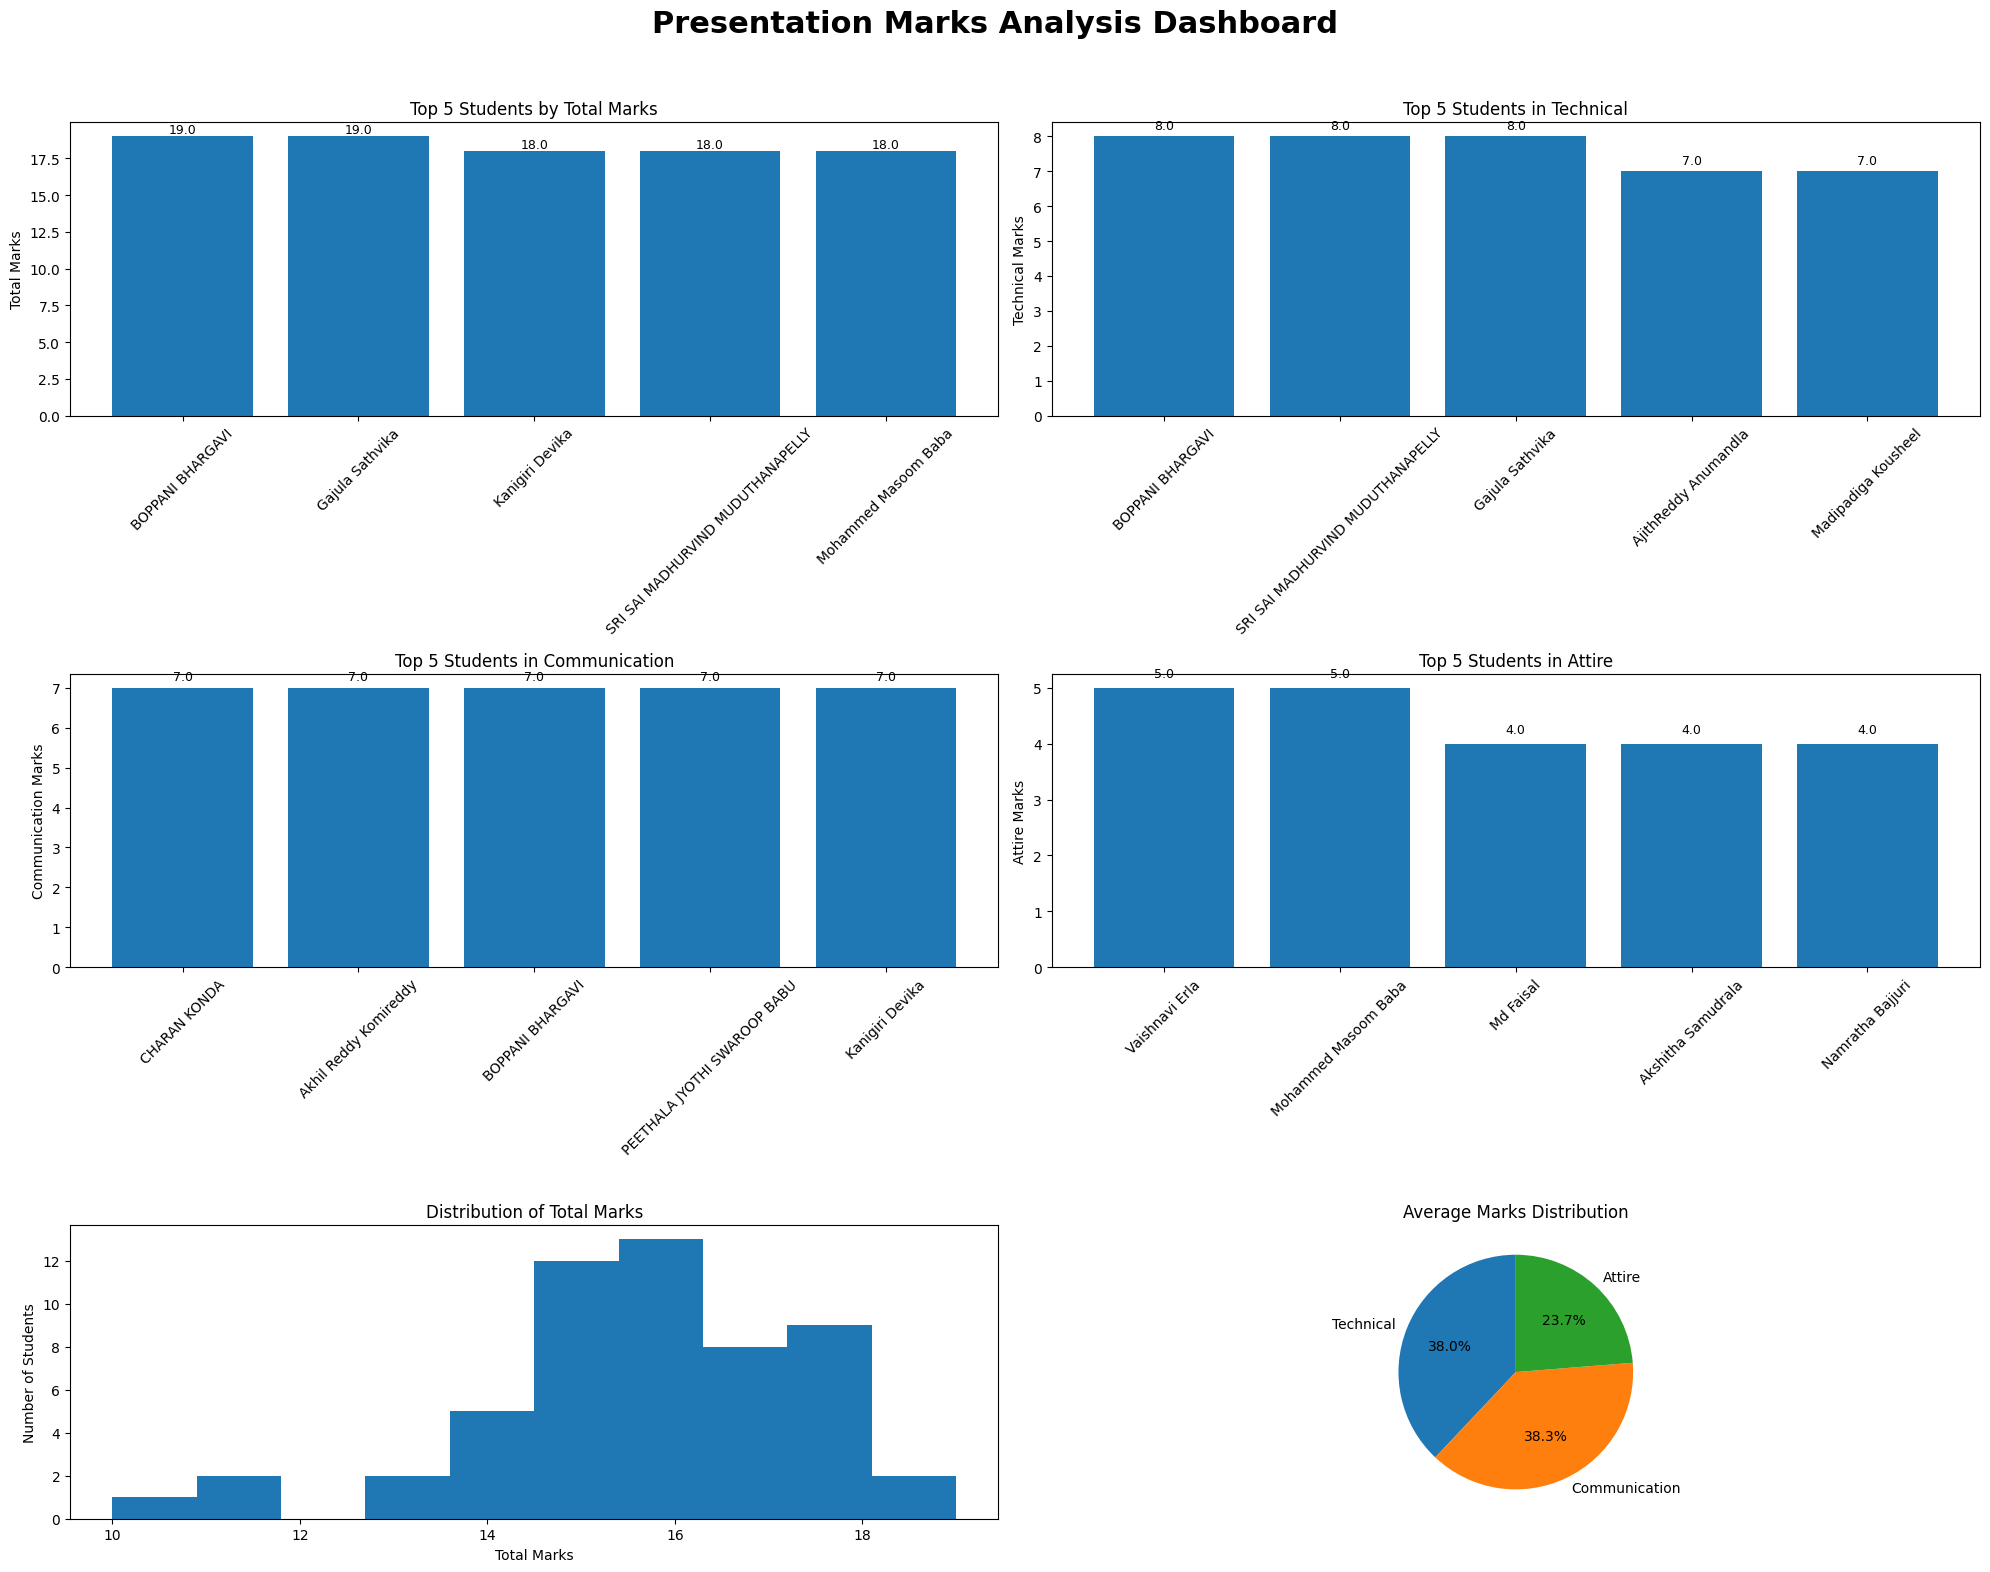

In [20]:
import matplotlib.pyplot as plt

# Create dashboard
fig, axes = plt.subplots(3, 2, figsize=(20, 16))

fig.suptitle(
    "Presentation Marks Analysis Dashboard",
    fontsize=22,
    fontweight="bold"
)

# ------------------- Top 5 Overall -------------------
axes[0,0].bar(top5_total["Participant Name"], top5_total["Total Marks"])
axes[0,0].set_title("Top 5 Students by Total Marks")
axes[0,0].set_ylabel("Total Marks")
axes[0,0].tick_params(axis='x', rotation=45)

for i, v in enumerate(top5_total["Total Marks"]):
    axes[0,0].text(i, v+0.2, str(v), ha='center', fontsize=9)

# ------------------- Technical -------------------
axes[0,1].bar(top_technical["Participant Name"], top_technical["Technical knowledge"])
axes[0,1].set_title("Top 5 Students in Technical")
axes[0,1].set_ylabel("Technical Marks")
axes[0,1].tick_params(axis='x', rotation=45)

for i, v in enumerate(top_technical["Technical knowledge"]):
    axes[0,1].text(i, v+0.2, str(v), ha='center', fontsize=9)

# ------------------- Communication -------------------
axes[1,0].bar(top_communication["Participant Name"], top_communication["Communication"])
axes[1,0].set_title("Top 5 Students in Communication")
axes[1,0].set_ylabel("Communication Marks")
axes[1,0].tick_params(axis='x', rotation=45)

for i, v in enumerate(top_communication["Communication"]):
    axes[1,0].text(i, v+0.2, str(v), ha='center', fontsize=9)

# ------------------- Attire -------------------
axes[1,1].bar(top_attire["Participant Name"], top_attire["Attrire"])
axes[1,1].set_title("Top 5 Students in Attire")
axes[1,1].set_ylabel("Attire Marks")
axes[1,1].tick_params(axis='x', rotation=45)

for i, v in enumerate(top_attire["Attrire"]):
    axes[1,1].text(i, v+0.2, str(v), ha='center', fontsize=9)

# ------------------- Histogram -------------------
axes[2,0].hist(df["Total Marks"], bins=10)
axes[2,0].set_title("Distribution of Total Marks")
axes[2,0].set_xlabel("Total Marks")
axes[2,0].set_ylabel("Number of Students")

# ------------------- Pie Chart -------------------
avg_marks = [
    df["Technical knowledge"].mean(),
    df["Communication"].mean(),
    df["Attrire"].mean()
]

labels = ["Technical", "Communication", "Attire"]

axes[2,1].pie(
    avg_marks,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
    )
axes[2,1].set_title("Average Marks Distribution")

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Save dashboard
plt.savefig("Presentation_Marks_Dashboard.png", dpi=300)

# Show dashboard
plt.show()


**Presentation Marks Analysis Report**

**1. Introduction**      
     This project focuses on analyzing the presentation evaluation scores of participants to determine their overall performance as well as their strengths in individual assessment categories. The analysis was carried out using Python, Pandas, and Matplotlib in Google Colab, enabling efficient data processing, ranking, and visualization.

**2. Project Objective**

The primary objectives of this analysis were to:



*   Clean and prepare the presentation marks dataset.
*   Calculate the total marks obtained by each participant.

*   Identify the highest-performing participants overall.
*   Determine the top performers in Technical Knowledge, Communication, and Attire.

*   Create visualizations that summarize participant performance.










**3. Dataset Overview**

The dataset contains presentation evaluation details of all participants.

**Dataset Fields**


*  UID
*  Participant Name

*  Project Name
*  Technical Knowledge

*  Communication
*  Attire

*  Total Marks











**4. Data Preparation**

Before performing the analysis, the dataset was preprocessed using the following steps:


*   Imported the dataset into Google Colab using Pandas.
*   Checked the dataset for missing values.

*   Removed all records containing null values.
*   Kept duplicate entries unchanged as required.

*   Converted the scoring columns into numeric format.



Computed Total Marks using the formula:

Total Marks = Technical Knowledge + Communication + Attire

**5. Data Analysis**

The following analyses were conducted:


*   Computed total marks for every participant.
*   Ranked participants based on overall score.

Identified the top five performers in:

     

1.  Overall Marks
2.  Technical Knowledge

3.  Communication
4.  Attire

**6. Analysis Results**         
                 **A. Top 5 Overall Performers**

| Rank | Participant Name | Total Marks |
|------|-------------------------------|------------|
| 1 | BOPPANI BHARGAVI | 19.0 |
| 2 | Gajula Sathvika | 19.0 |
| 3 | Kanigiri Devika | 18.0 |
| 4 | SRI SAI MADHURVIND MUDUTHANAPELLY | 18.0 |
| 5 | Mohammed Masoom Baba | 18.0 ||

**Interpretation**

These participants maintained consistently high scores across all evaluation criteria, indicating balanced presentation skills and subject knowledge.


**B. Top 5 in Technical Knowledge**
| Rank | Participant Name                  | Technical Knowledge |
| ---- | --------------------------------- | ------------------- |
| 1    | BOPPANI BHARGAVI                  | 8.0                 |
| 2    | SRI SAI MADHURVIND MUDUTHANAPELLY | 8.0                 |
| 3    | Gajula Sathvika                   | 8.0                 |
| 4    | AjithReddy Anumandla              | 7.0                 |
| 5    | Madipadiga Kousheel               | 7.0                 |

**Interpretation**

The students listed above displayed excellent understanding of their project topics and answered technical questions confidently.

**C. Top 5 in Communication**
| Rank | Participant Name             | Communication |
| ---- | ---------------------------- | ------------- |
| 1    | CHARAN KONDA                 | 7.0           |
| 2    | Akhil Reddy Komireddy        | 7.0           |
| 3    | BOPPANI BHARGAVI             | 7.0           |
| 4    | PEETHALA JYOTHI SWAROOP BABU | 7.0           |
| 5    | Kanigiri Devika              | 7.0           |

**Interpretation**

These participants demonstrated excellent communication skills, including confidence, clarity, audience interaction, and effective delivery.

**D. Top 5 in Attire**

| Rank | Participant Name     | Attire |
| ---- | -------------------- | ------ |
| 1    | Vaishnavi Erla       | 5.0    |
| 2    | Mohammed Masoom Baba | 5.0    |
| 3    | Md Faisal            | 4.0    |
| 4    | Akshitha Samudrala   | 4.0    |
| 5    | Namratha Bajjuri     | 4.0    |

**Interpretation**

The highest scores in attire indicate participants who maintained a professional appearance throughout their presentations.

**7. Dashboard Summary**

A dashboard was designed using Matplotlib to visually present the analysis.

**Dashboard Components**


*   Top 5 Participants by Overall Marks
*   Top 5 in Technical Knowledge

*   Top 5 in Communication
*   Top 5 in Attire

*   Histogram showing Total Marks distribution
*   Pie Chart representing the average contribution of each evaluation criterion







The dashboard provides a quick and effective overview of participant performance.

**8. Major Observations**



*   Two participants, BOPPANI BHARGAVI and Gajula Sathvika, secured the highest overall score of 19 marks.
* Participants with high total marks generally performed consistently across all three evaluation categories.

*   Strong technical knowledge contributed significantly to overall performance.
*   Good communication skills improved presentation effectiveness.

*   Professional attire positively complemented participants' overall evaluation
*   The histogram revealed the spread of participant scores, while the pie chart illustrated the contribution of each assessment category







**9. Conclusion**

This project successfully analyzed presentation evaluation data using Python-based data analytics techniques. After cleaning and preprocessing the dataset, participant scores were evaluated to identify the best overall performers as well as the highest scorers in individual categories.

The generated dashboard made it easy to compare participant performance and interpret the evaluation results. This project demonstrates the practical application of data preprocessing, ranking, statistical analysis, and visualization in extracting meaningful insights from presentation assessment data.